# Domain-Shift Diagnostics and Transfer Evaluation for the Tennessee Eastman Process

**Goal**. We measure and visualize *how different* two domains, used in later experiments in transfer learning, are in the first place, using classical
distributional-discrepancy statistics. 

**How we define a "domain" In the TEP dataset** Each TEP fault is treated as a distinct operating domain,
because it corresponds to a qualitatively different failure mechanism (feed composition
drift, cooling—water failure, valve sticking, kinetic/reaction faults, etc.). A domain's data
consists of nominal (fault-free) windows plus windows recorded while that specific fault is
active.


**Methods used.**

| Method | What it measures |
|---|---|
| Maximum Mean Discrepancy (MMD, RBF kernel) | Global multivariate distributional divergence |
| Wasserstein / Earth Mover's distance (per feature) | Per-variable marginal shift, with direct physical units |
| Mahalanobis distance | Multivariate shift accounting for the source's covariance structure |
| Centroid (Euclidean) distance | Simple shift-in-mean baseline |
| PCA projection | Qualitative 2-D visualization of domain overlap/separation | 
| One-Class SVM / Isolation Forest "anomaly transfer" | Does a source-domain novelty detector flag the target as anomalous? |
| Multiclass mapping | Where does an unseen target fault land in a classifier trained only on source fault classes? |

**Scenarios.**
- **Scenario 1: One-to-one cross-fault transfer**: source = single fault; target = single fault.
- **Scenario 2: Many-to-one cross-fault transfer**: source = a group of related faults; target = one fault, with a "coherent" (physically related) group and a "control" (physically
  unrelated) group for contrast.
- **Scenario 3 Cross-run variability (same-domain noise floor)**: the *same* fault, but data
  from disjoint sets of simulation runs. It estimates how much distributional discrepancy is simply due to stochastic
  run-to-run variability, which calibrates how "large" a cross-fault discrepancy in
  Scenarios 1–2 really is.
- **Section 4: In-domain multiclass baseline**: the official TEP Train/Test split, all 20
  faults pooled, evaluated with standard supervised classifiers. This is a sanity-check
  baseline, not a transfer experiment.

**Notes on reproducibility.** All random seeds are fixed. All feature-engineering and
training code is deterministic given the seed. This notebook expects the raw TEP `.RData`
files to be available locally (see Section 1) — running it end-to-end requires access to that
data, which is not bundled with the notebook itself.


## 1. Setup and Configuration


In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyreadr  # reads the original .RData TEP files

from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

current_dir = Path(os.getcwd())
base_data_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"

save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)


## 2. Data Loading


In [3]:
RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}


def load_raw_tep_data(raw_files: dict) -> dict:
    """Load each TEP RData file, converting to CSV and caching on first use."""
    dfs = {}
    for key, filename in raw_files.items():
        csv_path = save_path / f"{key}.csv"

        if csv_path.exists():
            print(f"[cache] {key}: loading from {csv_path.name}")
            dfs[key] = pd.read_csv(csv_path)
            continue

        rdata_path = base_data_path / filename
        if not rdata_path.exists():
            raise FileNotFoundError(
                f"Could not find {filename} in {base_data_path}. "
                "Update `base_data_path` in Section 1 to point at your local copy "
                "of the TEP archive."
            )

        print(f"[convert] {key}: reading {filename} ...")
        r_data = pyreadr.read_r(rdata_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        dfs[key].to_csv(csv_path, index=False)
        print(f"[convert] {key}: cached to {csv_path.name}")

    return dfs


dfs = load_raw_tep_data(RAW_FILES)

df_fault_free_train = dfs["fault_free_train"]
df_fault_free_test = dfs["fault_free_test"]
df_faulty_train = dfs["faulty_train"]
df_faulty_test = dfs["faulty_test"]

SENSOR_COLUMNS = [c for c in df_fault_free_train.columns
                   if c not in ("faultNumber", "simulationRun", "sample")]

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")
print(f"Fault-free train shape: {df_fault_free_train.shape}")
print(f"Fault-free test shape:  {df_fault_free_test.shape}")
print(f"Faulty train shape:     {df_faulty_train.shape}")
print(f"Faulty test shape:      {df_faulty_test.shape}")


[cache] fault_free_train: loading from fault_free_train.csv
[cache] fault_free_test: loading from fault_free_test.csv
[cache] faulty_train: loading from faulty_train.csv
[cache] faulty_test: loading from faulty_test.csv

Sensor/actuator variables: 52
Fault-free train shape: (250000, 55)
Fault-free test shape:  (207252, 55)
Faulty train shape:     (5000000, 55)
Faulty test shape:      (9600000, 55)


## 3. Feature Engineering: Sliding-Window Statistical Descriptors


Raw TEP samples are noisy single time steps. We summarize each process variable over a
rolling window with seven descriptive statistics (`mean, std, min, p25, p50, p75, max`),
subsampling the raw signal first to reduce autocorrelation and computational cost. Each
resulting row is one labelled observation: `52 variables × 7 statistics = 364 features`.
A single cached extraction routine, keyed by `(fault_number, split)`, replaces the multiple
near-duplicate versions of this logic found across the original notebook's cells.

The **transient right after fault injection is discarded**: TEP injects the fault at sample
20 in the *Training* runs and at sample 160 in the *Testing* runs, so we drop samples before
that point, otherwise many windows would straddle the fault-free/faulty transition and get a
noisy, ambiguous label.


In [5]:
STAT_NAMES = ["mean", "std", "min", "p25", "p50", "p75", "max"]
FEATURE_NAMES = [f"{var}_{stat}" for var in SENSOR_COLUMNS for stat in STAT_NAMES]

WINDOW_SIZE = 30
STEP = 10
SUBSAMPLE = 5


def extract_window_features(df_raw: pd.DataFrame, split: str,
                             window_size: int = WINDOW_SIZE,
                             step: int = STEP,
                             subsample_rate: int = SUBSAMPLE) -> tuple[np.ndarray, np.ndarray, list]:
    """Turn raw TEP samples into rolling-window statistical features.

    `split` is "train" or "test" and determines the fault-injection cutoff sample
    (20 for the official Training runs, 160 for the official Testing runs); rows
    before the cutoff are dropped so windows never straddle the fault-free/faulty
    transition.
    """
    if df_raw.empty:
        return np.array([]), np.array([]), []

    inflection_point = 20 if split == "train" else 160
    if "sample" in df_raw.columns:
        df_raw = df_raw[df_raw["sample"] > inflection_point].copy()

    df_sub = df_raw.iloc[::subsample_rate].copy()
    grouped = df_sub.groupby("simulationRun") if "simulationRun" in df_sub.columns else [(None, df_sub)]

    all_feats, all_targets, all_ids = [], [], []

    for run_id, group in grouped:
        if len(group) < window_size:
            continue

        fault_label = group["faultNumber"].iloc[0] if "faultNumber" in group.columns else 0
        rolling = group[SENSOR_COLUMNS].rolling(window=window_size)

        stat_frames = {
            "mean": rolling.mean(), "std": rolling.std(), "min": rolling.min(),
            "p25": rolling.quantile(0.25), "p50": rolling.quantile(0.50),
            "p75": rolling.quantile(0.75), "max": rolling.max(),
        }
        for s_name in stat_frames:
            stat_frames[s_name] = stat_frames[s_name].iloc[window_size - 1::step]

        run_stats = pd.DataFrame({
            f"{col}_{s_name}": stat_frames[s_name][col]
            for s_name in STAT_NAMES for col in SENSOR_COLUMNS
        }).dropna()

        if run_stats.empty:
            continue

        all_feats.append(run_stats.values)
        all_targets.append(np.full(len(run_stats), fault_label))
        run_name = f"run_{run_id}" if run_id is not None else "run_all"
        all_ids.extend(f"{run_name}_w{idx * step}" for idx in range(len(run_stats)))

    if not all_feats:
        return np.array([]), np.array([]), []

    return np.vstack(all_feats), np.concatenate(all_targets), all_ids


def get_fault_features(fault_num: int, split: str, run_ids: list | None = None) -> tuple[np.ndarray, np.ndarray, list]:
    """Load (from cache, or extract) feature windows for one fault number and split.

    If `run_ids` is given, restrict to those specific simulation runs (used only
    by the cross-run variability test in Section 8 — that call bypasses the
    on-disk cache, since the cache key does not encode a run subset).
    """
    if run_ids is None:
        cache_file = features_path / f"fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}.csv"
        if cache_file.exists():
            df_cached = pd.read_csv(cache_file)
            return df_cached[FEATURE_NAMES].values, df_cached["target"].values, list(df_cached["id"])

    if fault_num == 0:
        df_raw = df_fault_free_train if split == "train" else df_fault_free_test
    else:
        df_source = df_faulty_train if split == "train" else df_faulty_test
        df_raw = df_source[df_source["faultNumber"] == fault_num]

    if run_ids is not None:
        df_raw = df_raw[df_raw["simulationRun"].isin(run_ids)]

    X, y, ids = extract_window_features(df_raw, split=split)
    if len(X) == 0:
        return np.array([]), np.array([]), []

    if run_ids is None:
        out = pd.DataFrame(X, columns=FEATURE_NAMES)
        out["target"] = y
        out["id"] = ids
        out.to_csv(cache_file, index=False)

    return X, y, ids


print("Pre-extracting / loading cached feature windows for all faults (test split)")
FAULT_FEATURES_TEST = {}
for fault_num in range(0, 21):
    X, y, ids = get_fault_features(fault_num, "test")
    FAULT_FEATURES_TEST[fault_num] = X
    print(f"  fault {fault_num:2d} [test]: {X.shape}")


Pre-extracting / loading cached feature windows for all faults (test split)
  fault  0 [test]: (1, 364)
  fault  1 [test]: (7000, 364)
  fault  2 [test]: (7000, 364)
  fault  3 [test]: (7000, 364)
  fault  4 [test]: (7000, 364)
  fault  5 [test]: (7000, 364)
  fault  6 [test]: (7000, 364)
  fault  7 [test]: (7000, 364)
  fault  8 [test]: (7000, 364)
  fault  9 [test]: (7000, 364)
  fault 10 [test]: (7000, 364)
  fault 11 [test]: (7000, 364)
  fault 12 [test]: (7000, 364)
  fault 13 [test]: (7000, 364)
  fault 14 [test]: (7000, 364)
  fault 15 [test]: (7000, 364)
  fault 16 [test]: (7000, 364)
  fault 17 [test]: (7000, 364)
  fault 18 [test]: (7000, 364)
  fault 19 [test]: (7000, 364)
  fault 20 [test]: (7000, 364)


## 4. Building Source/Target DataFrames


In [6]:
def build_domain_df(fault_ids: list, split: str = "test") -> pd.DataFrame:
    """Concatenate feature windows for a list of fault ids into one labelled DataFrame."""
    parts = []
    for f in fault_ids:
        X, y, _ = get_fault_features(f, split) if split != "test" else (FAULT_FEATURES_TEST[f], None, None)
        if split == "test":
            X = FAULT_FEATURES_TEST[f]
            y = np.full(len(X), f)
        if len(X) == 0:
            continue
        df = pd.DataFrame(X, columns=FEATURE_NAMES)
        df["target"] = y
        parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=FEATURE_NAMES + ["target"])


## 5. Distributional Discrepancy Metrics

Four complementary statistics quantify "how different" a source and a target domain are, in
the same standardized feature space every time.

- **MMD (RBF kernel)**: a global, non-parametric two-sample statistic; 0 means the two samples
  are indistinguishable, larger values mean more divergent distributions.
- **Wasserstein distance**: computed per feature, then summarized (mean, and worst-offending
  feature). This is directly interpretable as "how far you'd have to move probability mass",
  measured on the source-scaler-standardized axis.
- **Mahalanobis distance**: how many source-domain standard deviations (accounting for
  correlations) the target centroid sits from the source centroid.
- **Centroid distance**: a simple Euclidean baseline.


In [26]:
def compute_mmd(X: np.ndarray, Y: np.ndarray, max_samples: int = 10_000) -> float:
    """Maximum Mean Discrepancy with an RBF kernel, gamma = 1 / n_features (median-heuristic proxy)."""
    rng = np.random.default_rng(SEED)
    if len(X) > max_samples:
        X = X[rng.choice(len(X), max_samples, replace=False)]
    if len(Y) > max_samples:
        Y = Y[rng.choice(len(Y), max_samples, replace=False)]
    gamma = 1.0 / X.shape[1]
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())


def compute_mahalanobis(source_scaled: np.ndarray, target_scaled: np.ndarray) -> float:
    """Average Mahalanobis distance of target points from the source centroid,
    using the source's covariance (diagonally regularized for numerical stability)."""
    mean_vec = source_scaled.mean(axis=0)
    cov = np.cov(source_scaled, rowvar=False) + np.eye(source_scaled.shape[1]) * 1e-5
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        inv_cov = np.linalg.pinv(cov)
    diff = target_scaled - mean_vec
    return float(np.mean(np.sqrt(np.sum((diff @ inv_cov) * diff, axis=1))))


def compute_centroid_distance(source_scaled: np.ndarray, target_scaled: np.ndarray) -> float:
    """Euclidean distance between the two domains' feature-space centroids."""
    return float(np.linalg.norm(source_scaled.mean(axis=0) - target_scaled.mean(axis=0)))


def evaluate_domain_shift(df_source: pd.DataFrame, df_target: pd.DataFrame,
                           feature_names: list, pair_name: str,
                           top_n: int = 10, make_plot: bool = True) -> dict:
    """Compute all four discrepancy metrics for a source -> target pair, in a
    single scaler fit on the source domain, and plot the top-N most shifted
    features by Wasserstein distance."""
    scaler = StandardScaler().fit(df_source[feature_names])
    s_scaled = scaler.transform(df_source[feature_names])
    t_scaled = scaler.transform(df_target[feature_names])

    mmd_val = compute_mmd(s_scaled, t_scaled)
    w_distances = [wasserstein_distance(s_scaled[:, i], t_scaled[:, i]) for i in range(len(feature_names))]
    mahal_val = compute_mahalanobis(s_scaled, t_scaled)
    centroid_val = compute_centroid_distance(s_scaled, t_scaled)

    avg_w, max_w = float(np.mean(w_distances)), float(np.max(w_distances))

    print(f"Evaluation of {pair_name}")
    print(f"MMD: {mmd_val:.5f}")
    print(f"Wasserstein (avg feature): {avg_w:.5f}")
    print(f"Wasserstein (max feature): {max_w:.5f}")
    print(f"Mahalanobis (target centroid vs source): {mahal_val:.3f}")
    print(f"Centroid distance (Euclidean): {centroid_val:.5f}")

    if make_plot:
        df_sorted = (pd.DataFrame({"Feature": feature_names, "Wasserstein": w_distances})
                       .sort_values("Wasserstein", ascending=False)
                       .head(top_n)
                       .set_index("Feature"))
        plt.figure(figsize=(6, max(3, top_n * 0.3)))
        sns.heatmap(df_sorted, cmap="crest", annot=True, fmt=".2f", cbar=True,
                    cbar_kws={"label": "Wasserstein distance (source-std units)"}, linewidths=0.5)
        plt.title(f"Top {top_n} Most-Shifted Features: {pair_name}", fontsize=10)
        plt.ylabel("TEP process variable")
        plt.tight_layout()
        plt.show()

    return {"Scenario": pair_name, "MMD": mmd_val, "Wasserstein_Avg": avg_w,
            "Wasserstein_Max": max_w, "Mahalanobis": mahal_val, "Centroid_Distance": centroid_val}


## 6. Qualitative Visualization: PCA Domain Overlap


In [ ]:
def plot_domain_pca(source_df: pd.DataFrame, target_df: pd.DataFrame,
                     source_name: str, target_name: str, feature_names: list,
                     sample_size: int = 5000, ax=None) -> None:
    """2-D PCA projection (fit on the pooled source+target sample) to visualize
    how separated the two domains are in feature space."""
    n = min(sample_size, len(source_df), len(target_df))
    src = source_df.sample(n, random_state=SEED).copy()
    tgt = target_df.sample(n, random_state=SEED).copy()
    src["Domain"], tgt["Domain"] = source_name, target_name
    combined = pd.concat([src, tgt], ignore_index=True)

    X_scaled = StandardScaler().fit_transform(combined[feature_names])
    proj = PCA(n_components=2, random_state=SEED).fit_transform(X_scaled)
    combined["PCA1"], combined["PCA2"] = proj[:, 0], proj[:, 1]

    if ax is None:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=combined, x="PCA1", y="PCA2", hue="Domain",
                        alpha=0.4, s=20, palette=["#1f77b4", "#ff7f0e"])
        plt.title(f"PCA of the Statistical Feature Space: {source_name} vs {target_name}", fontweight="bold")
        plt.legend(title="Domain")
        plt.tight_layout()
        plt.show()
    else:
        # Altrimenti disegniamo sul subplot passato dall'esterno
        sns.scatterplot(data=combined, x="PCA1", y="PCA2", hue="Domain",
                        alpha=0.4, s=20, palette=["#1f77b4", "#ff7f0e"], ax=ax)
        ax.set_title(f"PCA: {source_name} vs {target_name}", fontweight="bold", fontsize=10)
        ax.legend(title="Domain", fontsize=8)



def plot_domain_pca_grid(scenarios: dict, feature_names: list, sample_size: int = 5000, scenario_name: str = None) -> None:
    """Creates a grid of subplots calling plot_domain_pca for each scenario."""
    n_scenarios = len(scenarios)
    n_cols = 3
    n_rows = (n_scenarios + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = axes.flatten()
    
    for idx, (name, cfg) in enumerate(scenarios.items()):
        ax = axes[idx]
        source_df = build_domain_df(cfg["source"], split="test")
        target_df = build_domain_df([cfg["target"]], split="test")
        
        source_name = f"Fault {cfg['source']}"
        target_name = f"Fault {cfg['target']}"
        
        plot_domain_pca(source_df, target_df, source_name, target_name, 
                        feature_names, sample_size=sample_size, ax=ax)
        
        ax.set_title(f"{name}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, loc='upper right', fontsize=10, title=None)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(f"2D PCA Projections: {scenario_name} Scenarios", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Transfer Evaluation Tools

Two complementary, model-based ways to probe transfer, in addition to the pure discrepancy
statistics above.

**Anomaly transfer.** Fit an unsupervised novelty detector (One-Class SVM, Isolation Forest)
on the source domain only, then apply it with no retraining to the target domain. A high
`Target_Anomaly_Rate` means the source-trained notion of "normal" does **not** cover the
target: the two domains are behaviorally distinct from the model's point of view. 

**Multiclass mapping.** Train a standard multiclass classifier on the source domain's fault
labels only, then predict on the target domain (whose true label the classifier has never
seen). This does **not** measure classification accuracy, as the target's true fault label is
outside the classifier's label space by construction. It is a *qualitative diagnostic*
showing which known fault(s) the unseen target fault most resembles from the model's learned
decision boundaries.


In [52]:
def evaluate_anomaly_transfer(df_source: pd.DataFrame, df_target: pd.DataFrame,
                               feature_names: list, source_name: str, target_name: str) -> dict:
    scaler = StandardScaler().fit(df_source[feature_names])
    X_src = scaler.transform(df_source[feature_names])
    X_tgt = scaler.transform(df_target[feature_names])

    models = {
        "OC-SVM": OneClassSVM(kernel="rbf", gamma="scale", nu=0.05),
        "IsolationForest": IsolationForest(contamination=0.05, random_state=SEED),
    }

    result = {"Source": source_name, "Target": target_name}
    print(f"Anomaly-transfer evaluation: {source_name} -> {target_name}")
    for name, model in models.items():
        model.fit(X_src)
        inlier_rate_source = float(np.mean(model.predict(X_src) == 1))
        anomaly_rate_target = float(np.mean(model.predict(X_tgt) == -1))
        result[f"{name}_Source_Inlier_Rate"] = inlier_rate_source
        result[f"{name}_Target_Anomaly_Rate"] = anomaly_rate_target
        print(f"  [{name}] source inlier rate: {inlier_rate_source:.4f} | target anomaly rate (shift): {anomaly_rate_target:.4f}")
    print("")
    return result


def evaluate_multiclass_transfer(df_source: pd.DataFrame, df_target: pd.DataFrame,
                                  feature_names: list, source_name: str, target_name: str) -> None:
    """Qualitative diagnostic: where does the target fault land in a classifier
    trained only on the source domain's fault classes?"""
    scaler = StandardScaler().fit(df_source[feature_names])
    X_src_scaled = scaler.transform(df_source[feature_names])
    y_src = df_source["target"].values
    X_tgt_scaled = scaler.transform(df_target[feature_names])

    models = {
        "RF": RandomForestClassifier(n_estimators=100, random_state=SEED),
        "SVM": SVC(kernel="rbf", random_state=SEED),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=SEED),
    }

    fig, axes = plt.subplots(1, len(models), figsize=(15, 4), sharey=True)
    print(f"Evaluation of multiclass transfer: {source_name} -> {target_name}")
    for idx, (name, model) in enumerate(models.items()):
        model.fit(X_src_scaled, y_src)
        preds = model.predict(X_tgt_scaled)
        classes, counts = np.unique(preds, return_counts=True)
        pct = counts / len(preds) * 100
        print(f"  [{name}] mapping: " + " | ".join(f"class {c}: {p:.1f}%" for c, p in zip(classes, pct)))

        ax = axes[idx]
        sns.barplot(x=classes, y=pct, hue=classes, palette="Blues_d", legend=False, ax=ax)
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("Source fault classes")
        ax.set_ylabel("Mapping share (%)" if idx == 0 else "")
        ax.set_ylim(0, 110)
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2, h),
                            ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")

    plt.suptitle(f"Target Mapping: {target_name} on Source Model {source_name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


## 8. Scenario 1: One-to-One Cross-Fault Transfer

### Motivation
Process physics suggests some fault pairs share underlying dynamics (e.g. step-change feed
faults) while others are fundamentally different failure mechanisms (e.g. a sudden feed loss
vs. a slow kinetic drift). Here we test whether the discrepancy statistics and transfer
diagnostics reflect that expected structure.

### Source/target definition
- **Source**: `faulty_test` windows for a single fault `i`.
- **Target**: `faulty_test` windows for a different fault `j`.


Evaluation of F1 -> F2
MMD: 0.47699
Wasserstein (avg feature): 5.43738
Wasserstein (max feature): 78.32583
Mahalanobis (target centroid vs source): 271.511
Centroid distance (Euclidean): 243.74431


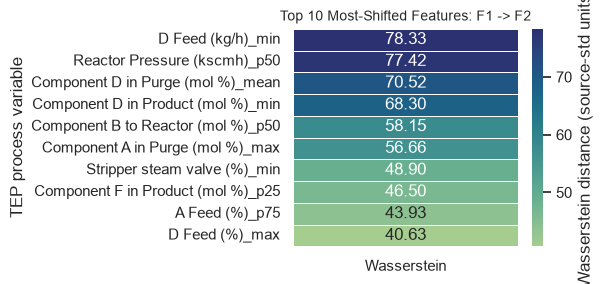

Anomaly-transfer evaluation: Fault [1] -> Fault 2
  [OC-SVM] source inlier rate: 0.9499 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.9933

Evaluation of F2 -> F6
MMD: 0.23026
Wasserstein (avg feature): 24.25602
Wasserstein (max feature): 409.37870
Mahalanobis (target centroid vs source): 5500.761
Centroid distance (Euclidean): 656.10554


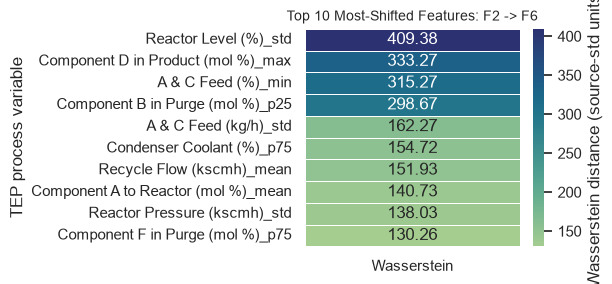

Anomaly-transfer evaluation: Fault [2] -> Fault 6
  [OC-SVM] source inlier rate: 0.9496 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 1.0000

Evaluation of F6 -> F10
MMD: 0.28374
Wasserstein (avg feature): 108.26737
Wasserstein (max feature): 11469.61419
Mahalanobis (target centroid vs source): 18690.568
Centroid distance (Euclidean): 15772.83846


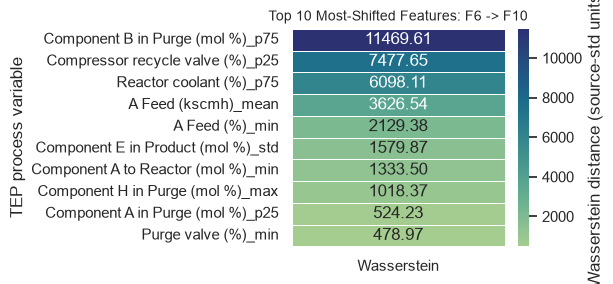

Anomaly-transfer evaluation: Fault [6] -> Fault 10
  [OC-SVM] source inlier rate: 0.9491 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 1.0000

Evaluation of F1 -> F18
MMD: 0.25948
Wasserstein (avg feature): 14.84385
Wasserstein (max feature): 213.10806
Mahalanobis (target centroid vs source): 2509.739
Centroid distance (Euclidean): 429.35034


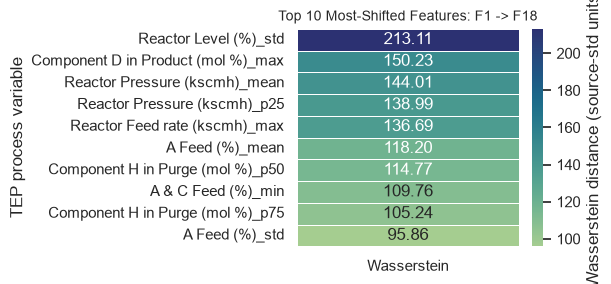

Anomaly-transfer evaluation: Fault [1] -> Fault 18
  [OC-SVM] source inlier rate: 0.9499 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.9904

Evaluation of F2 -> F8
MMD: 0.23033
Wasserstein (avg feature): 5.11467
Wasserstein (max feature): 29.93513
Mahalanobis (target centroid vs source): 148.386
Centroid distance (Euclidean): 137.77773


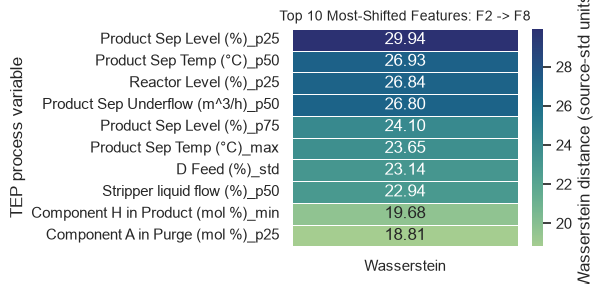

Anomaly-transfer evaluation: Fault [2] -> Fault 8
  [OC-SVM] source inlier rate: 0.9496 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 1.0000

Evaluation of F4 -> F5
MMD: 0.22282
Wasserstein (avg feature): 1.22258
Wasserstein (max feature): 41.54025
Mahalanobis (target centroid vs source): 490.441
Centroid distance (Euclidean): 76.87369


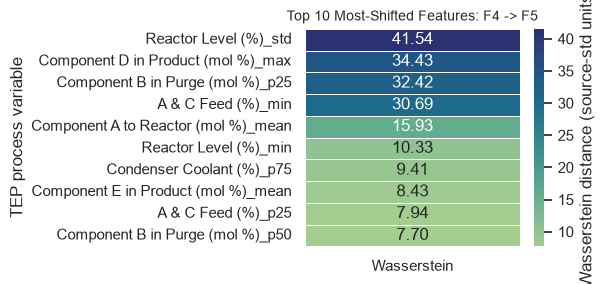

Anomaly-transfer evaluation: Fault [4] -> Fault 5
  [OC-SVM] source inlier rate: 0.9499 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.4339

Evaluation of F3 -> F10
MMD: 0.09246
Wasserstein (avg feature): 0.56859
Wasserstein (max feature): 5.34454
Mahalanobis (target centroid vs source): 68.822
Centroid distance (Euclidean): 17.58885


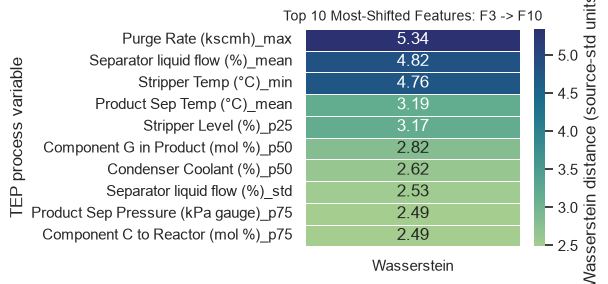

Anomaly-transfer evaluation: Fault [3] -> Fault 10
  [OC-SVM] source inlier rate: 0.9481 | target anomaly rate (shift): 0.8486
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.6530

Evaluation of F4 -> F14
MMD: 0.17039
Wasserstein (avg feature): 2.15847
Wasserstein (max feature): 93.19696
Mahalanobis (target centroid vs source): 182.361
Centroid distance (Euclidean): 205.65902


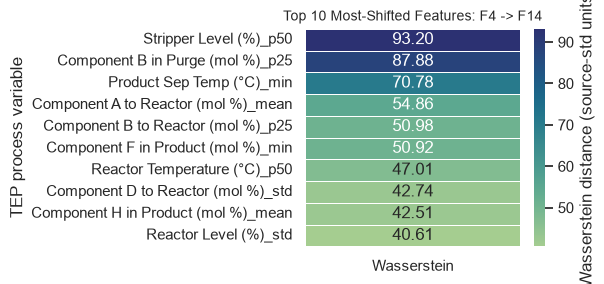

Anomaly-transfer evaluation: Fault [4] -> Fault 14
  [OC-SVM] source inlier rate: 0.9499 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.2931


Scenario 1 - discrepancy summary (sorted by average Wasserstein distance):


,Scenario,MMD,Wasserstein_Avg,Wasserstein_Max,Mahalanobis,Centroid_Distance
2,F6 -> F10,0.283736,108.267366,11469.614195,18690.567824,15772.838465
1,F2 -> F6,0.230257,24.256017,409.378697,5500.761196,656.105535
3,F1 -> F18,0.259484,14.843851,213.108057,2509.739126,429.350337
0,F1 -> F2,0.476992,5.437378,78.325830,271.510666,243.744308
4,F2 -> F8,0.230334,5.114670,29.935127,148.385568,137.777731
7,F4 -> F14,0.170392,2.158466,93.196958,182.361379,205.659021
5,F4 -> F5,0.222820,1.222576,41.540254,490.440767,76.873685
6,F3 -> F10,0.092459,0.568590,5.344537,68.821957,17.588854



Scenario 1 - anomaly transfer summary:


,Source,Target,OC-SVM_Source_Inlier_Rate,OC-SVM_Target_Anomaly_Rate,IsolationForest_Source_Inlier_Rate,IsolationForest_Target_Anomaly_Rate
0,Fault [1],Fault 2,0.949857,1.000000,0.95,0.993286
1,Fault [2],Fault 6,0.949571,1.000000,0.95,1.000000
2,Fault [6],Fault 10,0.949143,1.000000,0.95,1.000000
3,Fault [1],Fault 18,0.949857,1.000000,0.95,0.990429
4,Fault [2],Fault 8,0.949571,1.000000,0.95,1.000000
5,Fault [4],Fault 5,0.949857,1.000000,0.95,0.433857
6,Fault [3],Fault 10,0.948143,0.848571,0.95,0.653000
7,Fault [4],Fault 14,0.949857,1.000000,0.95,0.293143


In [34]:
one_to_one_scenarios = {
    "F1 -> F2":  {"source": [1], "target": 2},
    "F2 -> F6":  {"source": [2], "target": 6},
    "F6 -> F10": {"source": [6], "target": 10},
    "F1 -> F18": {"source": [1], "target": 18},
    "F2 -> F8":  {"source": [2], "target": 8},
    "F4 -> F5":  {"source": [4], "target": 5},
    "F3 -> F10": {"source": [3], "target": 10},
    "F4 -> F14": {"source": [4], "target": 14},
}

scenario1_discrepancy = []
scenario1_anomaly_transfer = []

for name, cfg in one_to_one_scenarios.items():
    source_df = build_domain_df(cfg["source"], split="test")
    target_df = build_domain_df([cfg["target"]], split="test")
    pair_name = f"F{'+'.join(map(str, cfg['source']))} -> F{cfg['target']}"

    scenario1_discrepancy.append(
        evaluate_domain_shift(source_df, target_df, FEATURE_NAMES, pair_name, top_n=10)
    )
    scenario1_anomaly_transfer.append(
        evaluate_anomaly_transfer(source_df, target_df, FEATURE_NAMES,
                                   f"Fault {cfg['source']}", f"Fault {cfg['target']}")
    )

df_scenario1_discrepancy = pd.DataFrame(scenario1_discrepancy)
df_scenario1_anomaly = pd.DataFrame(scenario1_anomaly_transfer)
print("\nScenario 1 - discrepancy summary (sorted by average Wasserstein distance):")
display(df_scenario1_discrepancy.sort_values("Wasserstein_Avg", ascending=False))

print("\nScenario 1 - anomaly transfer summary:")
display(df_scenario1_anomaly)



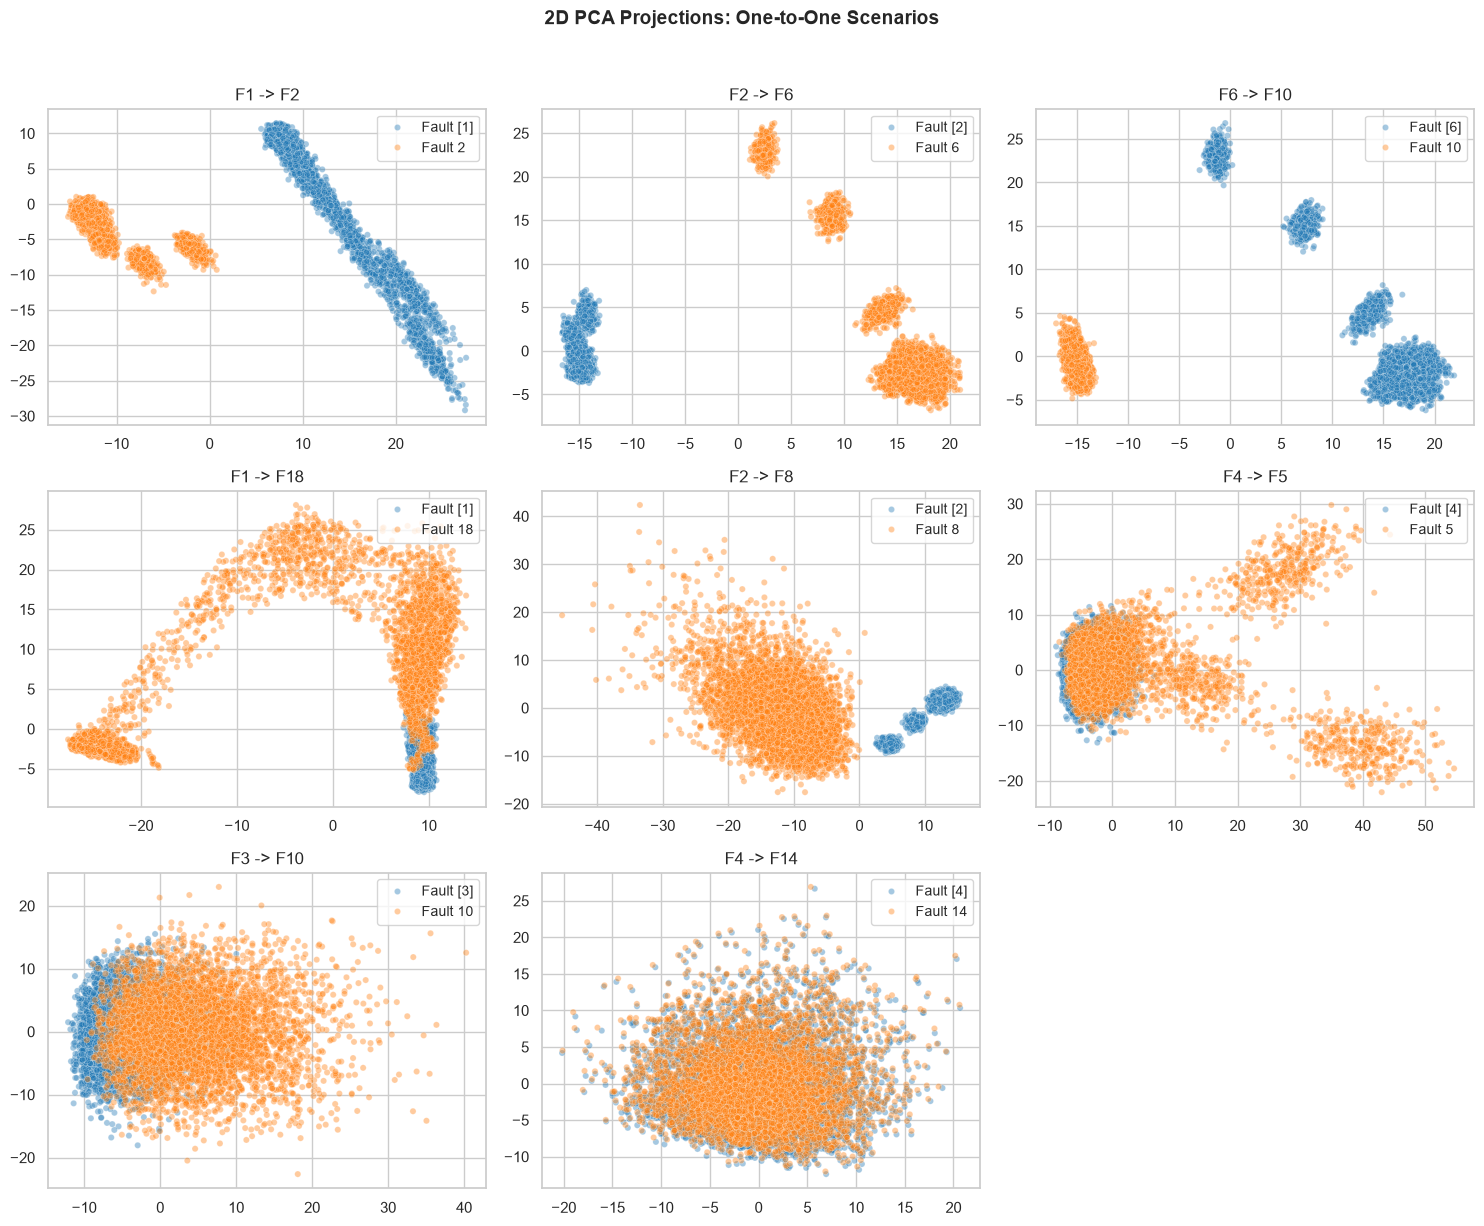

In [68]:

plot_domain_pca_grid(one_to_one_scenarios, FEATURE_NAMES, sample_size=5000, scenario_name="One-to-One")

## 9. Scenario 2: Many-to-One Cross-Fault Transfer

A group of **related** source faults (Group 1) is contrasted with a group of **unrelated**
source faults (Group 2, the control condition) against comparable targets.


Evaluation of (F1,F2) -> F6
MMD: 0.72488
Wasserstein (avg feature): 0.76028
Wasserstein (max feature): 14.59260
Mahalanobis (target centroid vs source): 110.512
Centroid distance (Euclidean): 31.26265


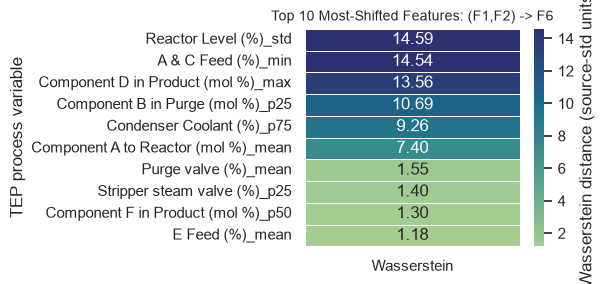

Anomaly-transfer evaluation: Faults [1, 2] -> Fault 4
  [OC-SVM] source inlier rate: 0.9498 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Faults [1, 2] -> Fault 4
  [RF] mapping: class 1: 100.0%
  [SVM] mapping: class 1: 100.0%
  [MLP] mapping: class 1: 3.0% | class 2: 97.0%


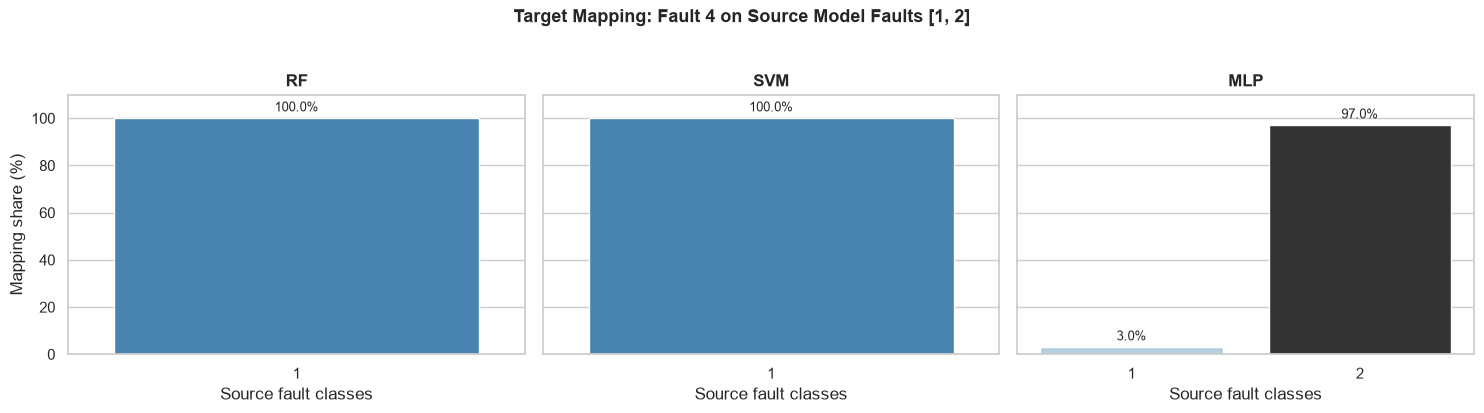

Evaluation of (F4,F5) -> F11
MMD: 0.44865
Wasserstein (avg feature): 0.41496
Wasserstein (max feature): 24.66854
Mahalanobis (target centroid vs source): 74.207
Centroid distance (Euclidean): 35.43414


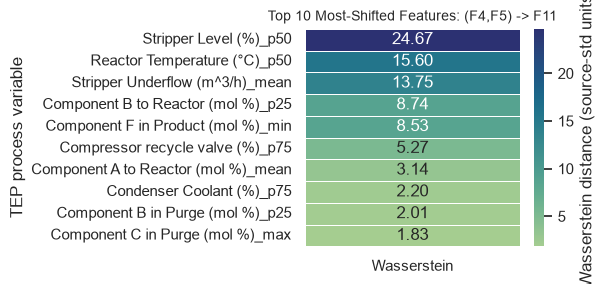

Anomaly-transfer evaluation: Faults [4, 5] -> Fault 11
  [OC-SVM] source inlier rate: 0.9501 | target anomaly rate (shift): 1.0000
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Faults [4, 5] -> Fault 11
  [RF] mapping: class 4: 99.8% | class 5: 0.2%
  [SVM] mapping: class 5: 100.0%
  [MLP] mapping: class 4: 0.8% | class 5: 99.2%


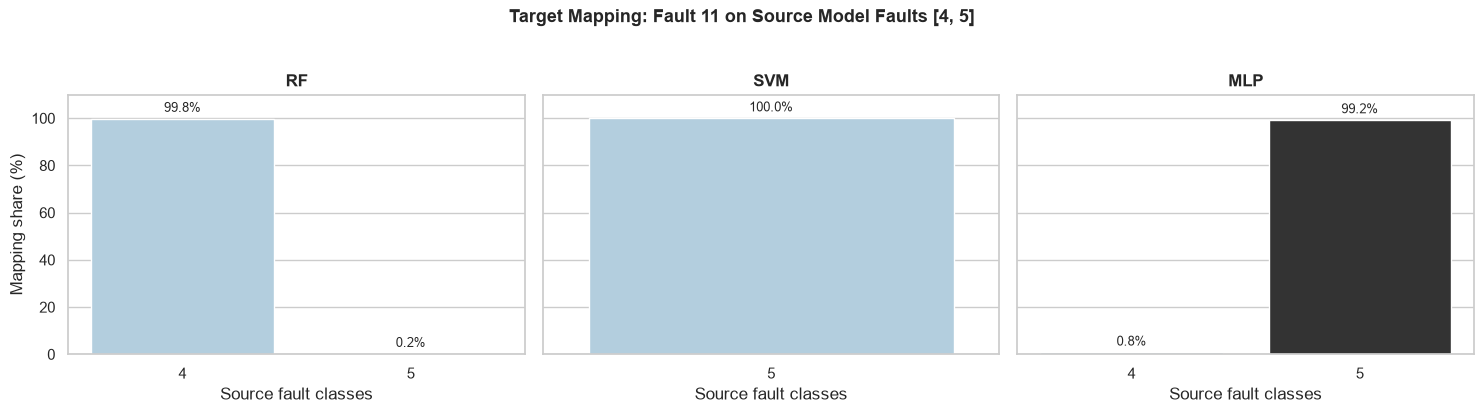

Evaluation of (F13,F14,F15) -> F18
MMD: 0.36302
Wasserstein (avg feature): 3.55823
Wasserstein (max feature): 11.47651
Mahalanobis (target centroid vs source): 126.053
Centroid distance (Euclidean): 74.21611


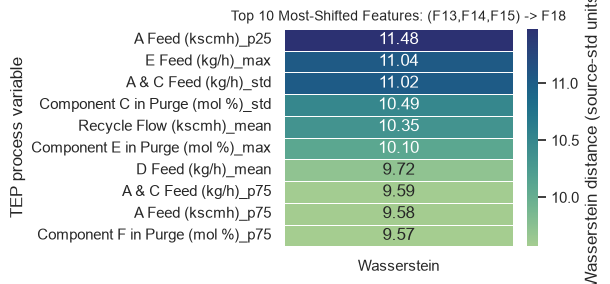

Anomaly-transfer evaluation: Faults [13, 14, 15] -> Fault 18
  [OC-SVM] source inlier rate: 0.9497 | target anomaly rate (shift): 0.9969
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.8559

Evaluation of multiclass transfer: Faults [13, 14, 15] -> Fault 18
  [RF] mapping: class 13: 99.9% | class 15: 0.1%
  [SVM] mapping: class 13: 99.9% | class 15: 0.1%
  [MLP] mapping: class 13: 99.8% | class 15: 0.2%


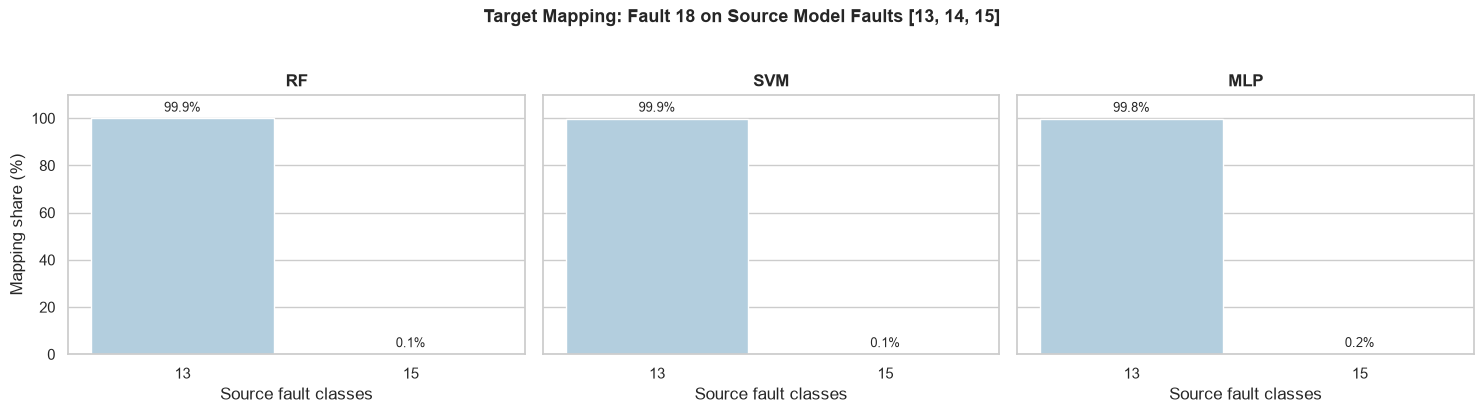

Evaluation of (F1,F2) -> F15
MMD: 0.29300
Wasserstein (avg feature): 0.56733
Wasserstein (max feature): 1.47877
Mahalanobis (target centroid vs source): 94.201
Centroid distance (Euclidean): 10.65050


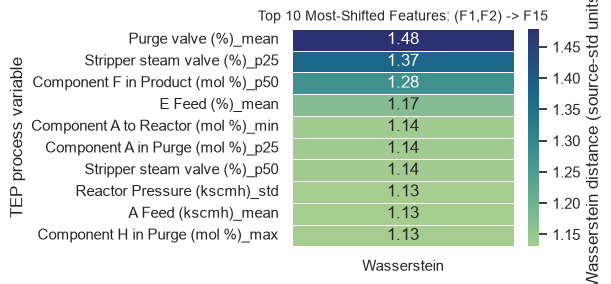

Anomaly-transfer evaluation: Faults [1, 2] -> Fault 15
  [OC-SVM] source inlier rate: 0.9498 | target anomaly rate (shift): 0.0703
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Faults [1, 2] -> Fault 15
  [RF] mapping: class 1: 100.0%
  [SVM] mapping: class 1: 100.0%
  [MLP] mapping: class 1: 100.0%


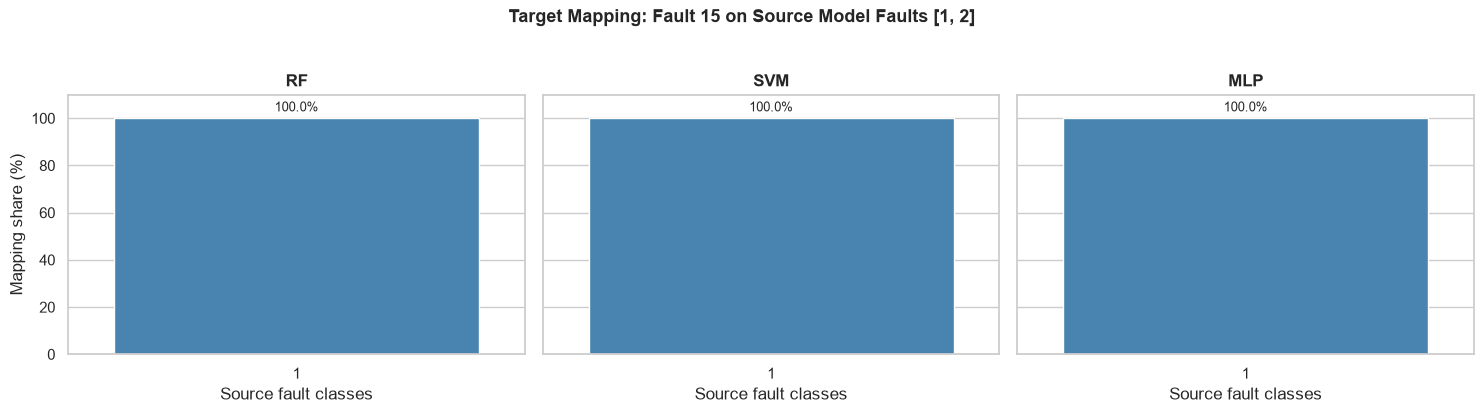

Evaluation of (F4,F5) -> F3
MMD: 0.03032
Wasserstein (avg feature): 0.19929
Wasserstein (max feature): 1.24719
Mahalanobis (target centroid vs source): 56.340
Centroid distance (Euclidean): 5.24354


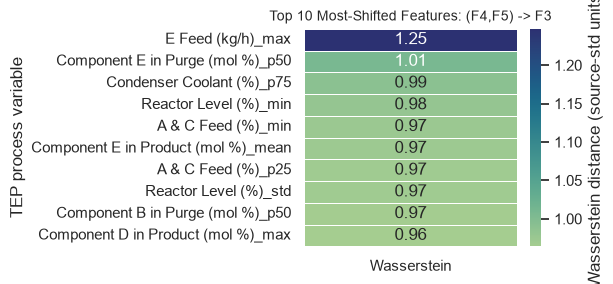

Anomaly-transfer evaluation: Faults [4, 5] -> Fault 3
  [OC-SVM] source inlier rate: 0.9501 | target anomaly rate (shift): 0.0154
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Faults [4, 5] -> Fault 3
  [RF] mapping: class 4: 0.1% | class 5: 99.9%
  [SVM] mapping: class 4: 89.1% | class 5: 10.9%
  [MLP] mapping: class 4: 45.8% | class 5: 54.2%


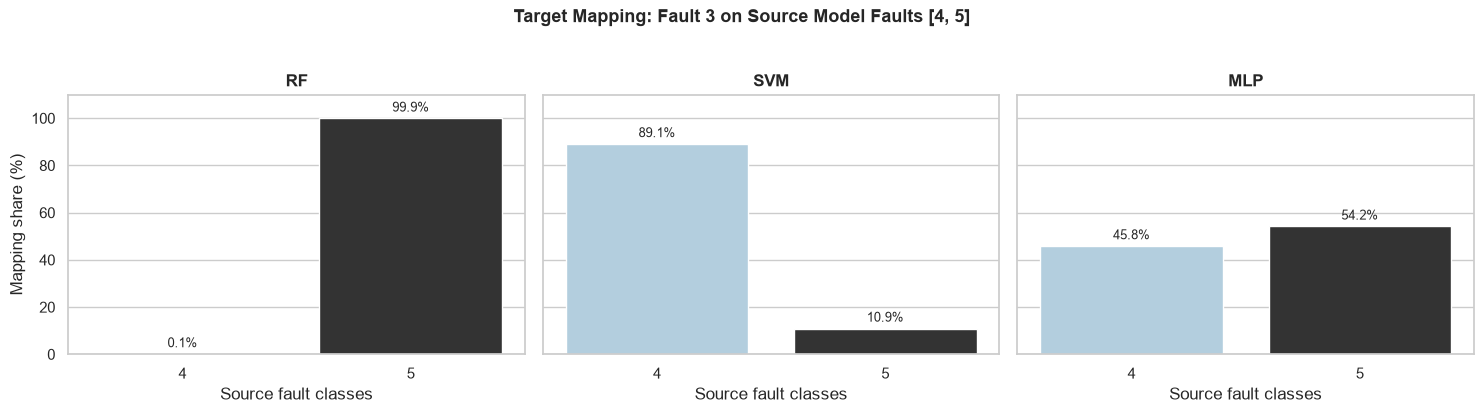

Evaluation of (F6,F7) -> F10
MMD: 0.36703
Wasserstein (avg feature): 0.80363
Wasserstein (max feature): 2.17826
Mahalanobis (target centroid vs source): 29.789
Centroid distance (Euclidean): 15.34406


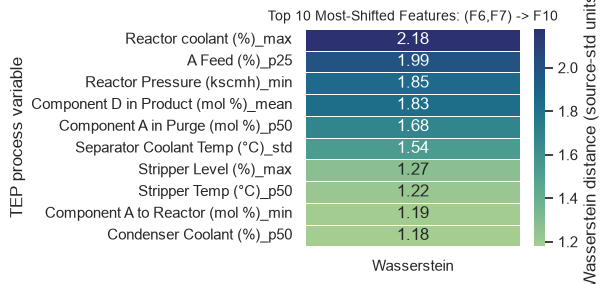

Anomaly-transfer evaluation: Faults [6, 7] -> Fault 10
  [OC-SVM] source inlier rate: 0.9499 | target anomaly rate (shift): 0.0477
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Faults [6, 7] -> Fault 10
  [RF] mapping: class 7: 100.0%
  [SVM] mapping: class 7: 100.0%
  [MLP] mapping: class 7: 100.0%


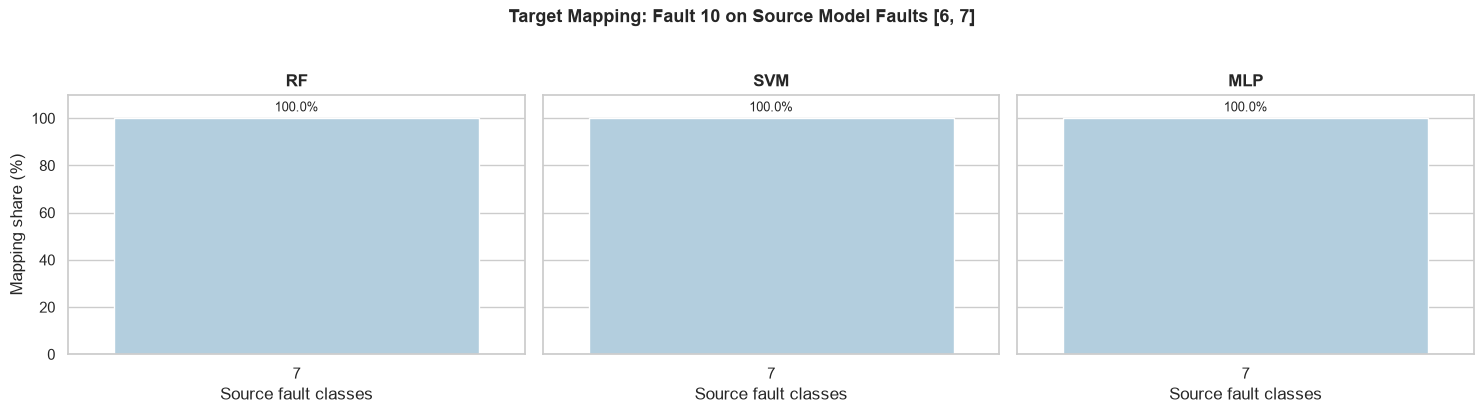

,Scenario,MMD,Wasserstein_Avg,Wasserstein_Max,Mahalanobis,Centroid_Distance,Group
0,"(F1,F2) -> F6",0.724884,0.760281,14.592599,110.512409,31.262646,Coherent
1,"(F4,F5) -> F11",0.448645,0.414956,24.668543,74.207437,35.434136,Coherent
2,"(F13,F14,F15) -> F18",0.363024,3.558233,11.476506,126.053297,74.216107,Coherent
3,"(F1,F2) -> F15",0.292996,0.567325,1.478770,94.201405,10.650499,Control
4,"(F4,F5) -> F3",0.030325,0.199291,1.247189,56.340493,5.243536,Control
5,"(F6,F7) -> F10",0.367033,0.803634,2.178259,29.789260,15.344057,Control


In [54]:
many_to_one_scenarios = {
    # Group 1: coherent (physically related source group -> related target)
    "(F1,F2) -> F6": {"source": [1, 2], "target": 4,  "group": "Coherent"}, # [feed group]
    "(F4,F5) -> F11": {"source": [4, 5], "target": 11, "group": "Coherent"}, # [thermal group]
    "(F13,F14,F15) -> F18": {"source": [13, 14, 15], "target": 18, "group": "Coherent"}, # [actuator group]

    # Group 2: control (related source group -> unrelated target)
    "(F1,F2) -> F15": {"source": [1, 2], "target": 15, "group": "Control"}, # [feed -> mechanical]
    "(F4,F5) -> F3": {"source": [4, 5], "target": 3,  "group": "Control"}, # [thermal -> feed]
    "(F6,F7) -> F10": {"source": [6, 7], "target": 10, "group": "Control"}, # [pressure -> kinetics]
}

scenario2_discrepancy = []
scenario2_anomaly_transfer = []

for name, cfg in many_to_one_scenarios.items():
    source_df = build_domain_df(cfg["source"], split="test")
    target_df = build_domain_df([cfg["target"]], split="test")

    disc = evaluate_domain_shift(source_df, target_df, FEATURE_NAMES, name, top_n=10)
    disc["Group"] = cfg["group"]
    scenario2_discrepancy.append(disc)

    anom = evaluate_anomaly_transfer(source_df, target_df, FEATURE_NAMES,
                                      f"Faults {cfg['source']}", f"Fault {cfg['target']}")
    anom["Group"] = cfg["group"]
    anom["Scenario"] = name
    scenario2_anomaly_transfer.append(anom)

    evaluate_multiclass_transfer(source_df, target_df, FEATURE_NAMES,
                                  f"Faults {cfg['source']}", f"Fault {cfg['target']}")

df_scenario2_discrepancy = pd.DataFrame(scenario2_discrepancy)
df_scenario2_anomaly = pd.DataFrame(scenario2_anomaly_transfer)
display(df_scenario2_discrepancy)


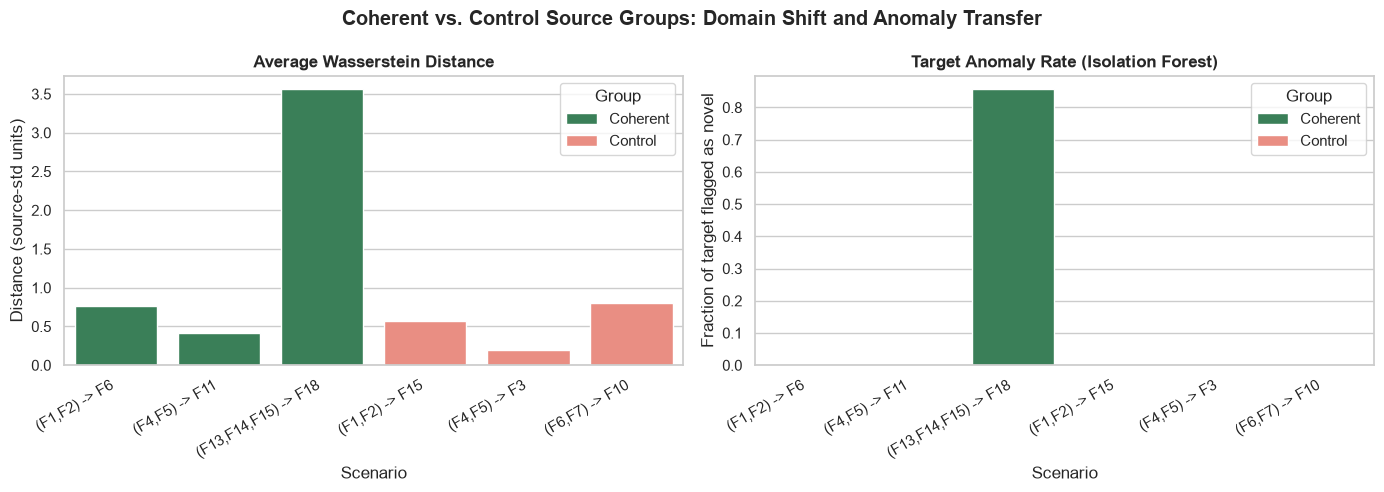

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_scenario2_discrepancy, x="Scenario", y="Wasserstein_Avg", hue="Group",
            palette={"Coherent": "seagreen", "Control": "salmon"}, ax=axes[0])
axes[0].set_title("Average Wasserstein Distance", fontweight="bold")
axes[0].set_ylabel("Distance (source-std units)")
axes[0].tick_params(axis="x", rotation=30)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

sns.barplot(data=df_scenario2_anomaly, x="Scenario", y="IsolationForest_Target_Anomaly_Rate", hue="Group",
            palette={"Coherent": "seagreen", "Control": "salmon"}, ax=axes[1])
axes[1].set_title("Target Anomaly Rate (Isolation Forest)", fontweight="bold")
axes[1].set_ylabel("Fraction of target flagged as novel")
axes[1].tick_params(axis="x", rotation=30)
for label in axes[1].get_xticklabels():
    label.set_ha("right")

plt.suptitle("Coherent vs. Control Source Groups: Domain Shift and Anomaly Transfer", fontweight="bold")
plt.tight_layout()
plt.show()


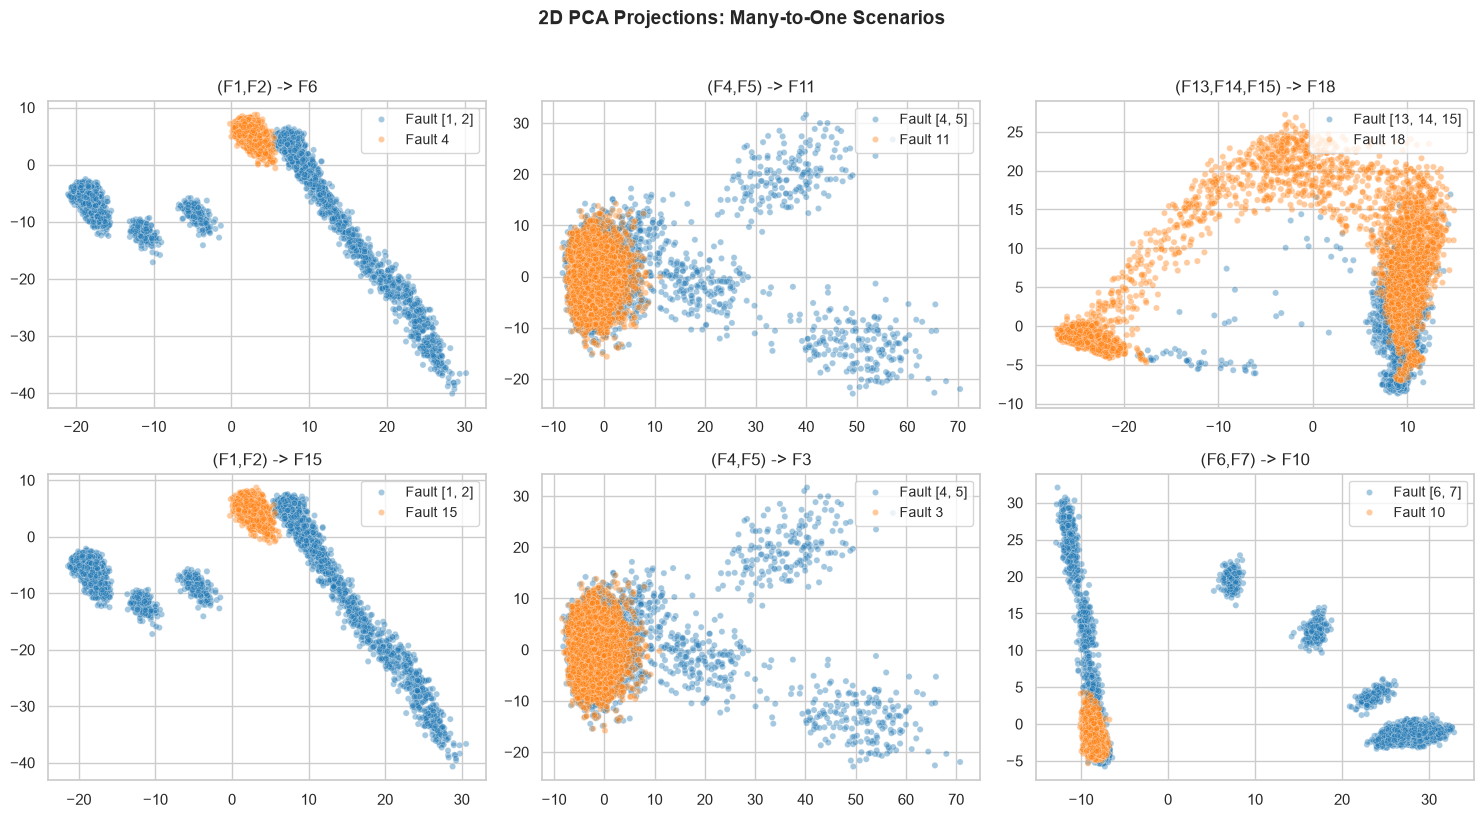

In [69]:
plot_domain_pca_grid(many_to_one_scenarios, FEATURE_NAMES, sample_size=5000, scenario_name="Many-to-One")

## 10. Scenario 3 — Cross-Run Variability (Same-Domain Noise Floor)
Scenarios 1 and 2 report discrepancy numbers between *different* faults, but without a
reference point we cannot tell whether a given MMD or Wasserstein value is "large" or "small".
This scenario measures the discrepancy between **two disjoint sets of simulation runs of the
very same fault**. The discrepancy we should expect purely from stochastic run-to-run
variability, with zero actual domain shift.

Fault 2: 500 runs total -> group A = 250 runs, group B = 250 runs
Evaluation of Fault 2 (Run Group A vs B)
MMD: 0.00087
Wasserstein (avg feature): 0.03376
Wasserstein (max feature): 0.10228
Mahalanobis (target centroid vs source): 19.937
Centroid distance (Euclidean): 0.57663


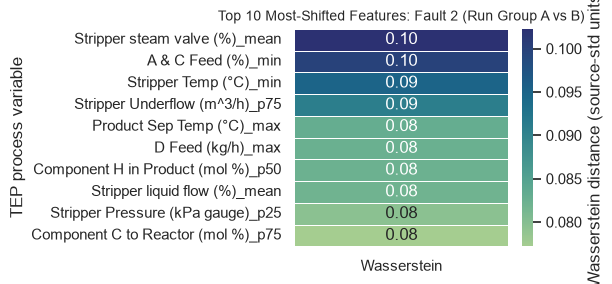

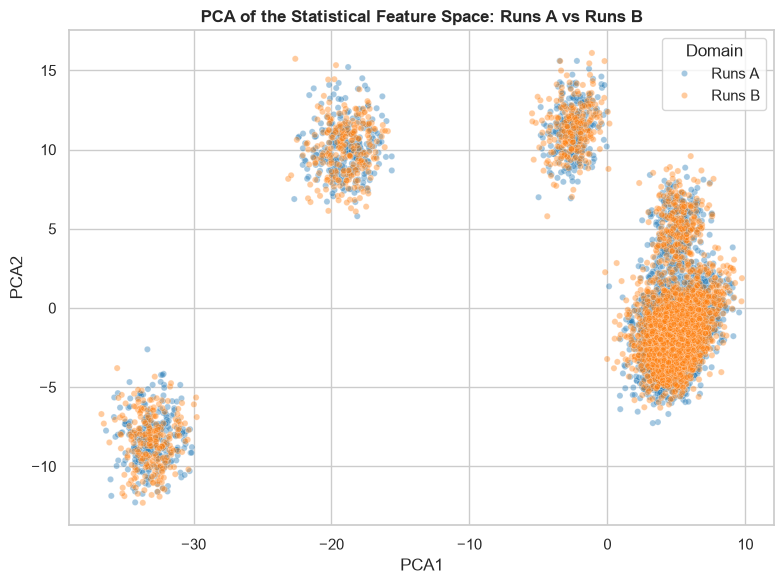

In [80]:
def get_runs_for_fault(fault_num: int, split: str = "test") -> np.ndarray:
    df_source = df_faulty_train if split == "train" else df_faulty_test
    return np.sort(df_source.loc[df_source["faultNumber"] == fault_num, "simulationRun"].unique())


def build_run_subset_df(fault_num: int, run_ids: list, split: str = "test") -> pd.DataFrame:
    X, y, _ = get_fault_features(fault_num, split, run_ids=run_ids)
    df = pd.DataFrame(X, columns=FEATURE_NAMES)
    df["target"] = y
    return df


CROSS_RUN_TEST_FAULT = 2 #Choose the fault to test

all_runs = get_runs_for_fault(CROSS_RUN_TEST_FAULT, split="test")
midpoint = len(all_runs) // 2
runs_a, runs_b = list(all_runs[:midpoint]), list(all_runs[midpoint:])
print(f"Fault {CROSS_RUN_TEST_FAULT}: {len(all_runs)} runs total -> "
      f"group A = {len(runs_a)} runs, group B = {len(runs_b)} runs")

df_run_a = build_run_subset_df(CROSS_RUN_TEST_FAULT, runs_a, split="test")
df_run_b = build_run_subset_df(CROSS_RUN_TEST_FAULT, runs_b, split="test")

noise_floor = evaluate_domain_shift(
    df_run_a, df_run_b, FEATURE_NAMES,
    f"Fault {CROSS_RUN_TEST_FAULT} (Run Group A vs B)",
    top_n=10,
)

plot_domain_pca(df_run_a, df_run_b, "Runs A", "Runs B", FEATURE_NAMES, sample_size=5000)


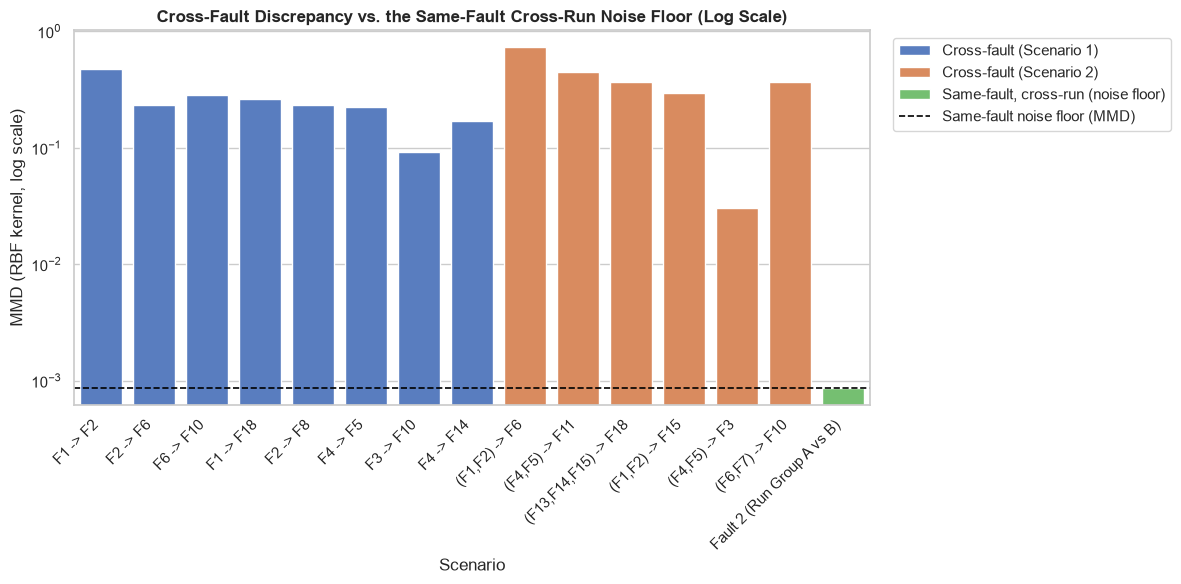

In [76]:
comparison_df = pd.concat([
    df_scenario1_discrepancy.assign(Type="Cross-fault (Scenario 1)"),
    df_scenario2_discrepancy[["Scenario", "MMD", "Wasserstein_Avg", "Wasserstein_Max",
                                "Mahalanobis", "Centroid_Distance"]].assign(Type="Cross-fault (Scenario 2)"),
    pd.DataFrame([noise_floor]).assign(Type="Same-fault, cross-run (noise floor)"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=comparison_df, x="Scenario", y="MMD", hue="Type", dodge=False, ax=ax)

ax.axhline(noise_floor["MMD"], color="black", linestyle="--", linewidth=1.2,
           label="Same-fault noise floor (MMD)")

ax.set_yscale('log')

ax.set_title("Cross-Fault Discrepancy vs. the Same-Fault Cross-Run Noise Floor (Log Scale)", fontweight="bold")
ax.set_ylabel("MMD (RBF kernel, log scale)")
ax.set_xlabel("Scenario")

plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Secttion 4: In-Domain Multiclass Baseline (Official Train/Test Split)
This section trains standard supervised classifiers on the
official TEP *Training* partition (all 20 faults pooled) and evaluates them on the official
*Testing* partition of the same faults. There is no source/target domain shift by
construction: this the classical in-domain generalization check, useful only as a sanity
baseline against which the genuine cross-domain results above should be contrasted.


In [77]:
ALL_FAULTS = list(range(1, 21))

def build_global_split_df(split: str) -> pd.DataFrame:
    parts = []
    for f in ALL_FAULTS:
        X, y, _ = get_fault_features(f, split)
        if len(X) == 0:
            continue
        df = pd.DataFrame(X, columns=FEATURE_NAMES)
        df["target"] = y
        parts.append(df)
    return pd.concat(parts, ignore_index=True)

global_train_df = build_global_split_df("train")
global_test_df = build_global_split_df("test")
print(f"Global train shape: {global_train_df.shape}")
print(f"Global test shape:  {global_test_df.shape}")


Global train shape: (70000, 365)
Global test shape:  (140000, 365)


In [ ]:
def evaluate_global_fault_classification(df_train: pd.DataFrame, df_test: pd.DataFrame,
                                           feature_names: list) -> dict:
    """Standard in-domain multiclass evaluation: fit on Train, score on Test, both
    covering the same 20 fault classes (official TEP split, not a transfer test)."""
    scaler = StandardScaler().fit(df_train[feature_names])
    X_train = scaler.transform(df_train[feature_names])
    X_test = scaler.transform(df_test[feature_names])
    y_train, y_test = df_train["target"].values, df_test["target"].values

    models = {
        "RF": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
        "SVM": SVC(kernel="rbf", random_state=SEED),
        "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=SEED),
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        train_f1 = f1_score(y_train, model.predict(X_train), average="weighted", zero_division=0)
        test_f1 = f1_score(y_test, model.predict(X_test), average="weighted", zero_division=0)
        results[name] = {"Train_F1": train_f1, "Test_F1": test_f1, "Generalization_Gap": train_f1 - test_f1}
        print(f"[{name}] Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {train_f1 - test_f1:.4f}")

    return results


global_classification_results = evaluate_global_fault_classification(
    global_train_df, global_test_df, FEATURE_NAMES
)
pd.DataFrame(global_classification_results).T


[RF] Train F1: 1.0000 | Test F1: 0.9282 | Gap: 0.0718
[SVM] Train F1: 0.9014 | Test F1: 0.8942 | Gap: 0.0072


Evaluation of Global: official Train split vs. official Test split (all faults pooled)
MMD: 0.00097
Wasserstein (avg feature): 0.10311
Wasserstein (max feature): 0.61986
Mahalanobis (target centroid vs source): 18.025
Centroid distance (Euclidean): 2.11565


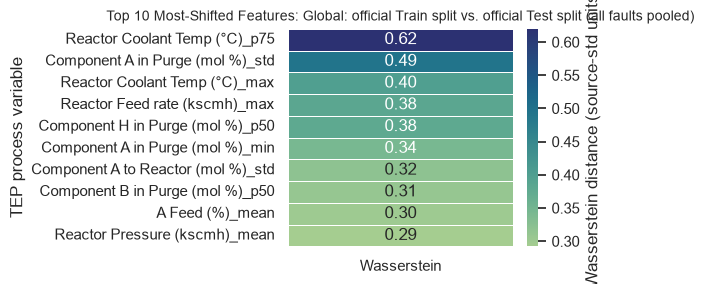

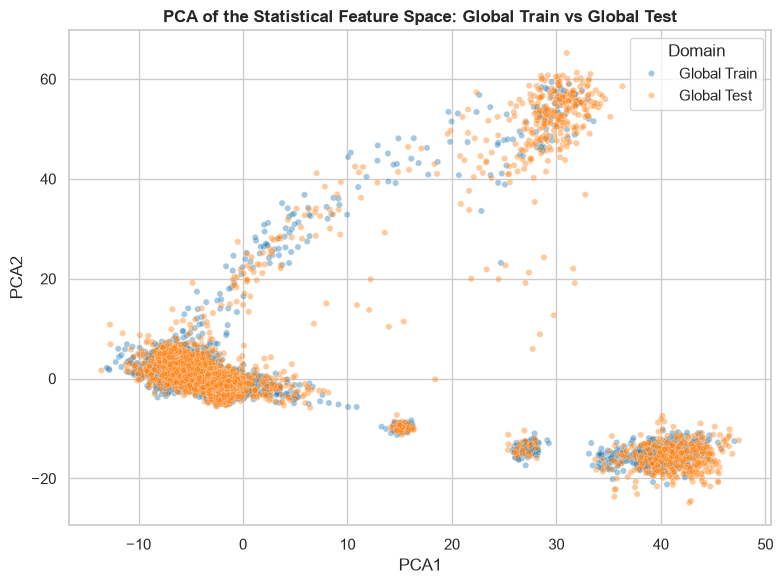

In [79]:
evaluate_domain_shift(global_train_df, global_test_df, FEATURE_NAMES,
                       "Global: official Train split vs. official Test split (all faults pooled)",
                       top_n=10)
plot_domain_pca(global_train_df, global_test_df, "Global Train", "Global Test",
                 FEATURE_NAMES, sample_size=10000)
